# **Лабораторная работа 1**
# **Задача о падении тела. Построение графиков функций**

Коровацкий Александр Сергеевич, 18.02.2025

# **Навыки**

1. базовые принципы работы с **Jupyter Notebook** (файлы с расширением .ipynb) в
**JupyterLab**:
      - типы ячеек: ячейка кода и текстовая ячейка
      - режимы ячеек: режим редактирования и командный режим
      - языки разметки **Markdown** и **Latex** для задания форматирования в тексте
2. базовый **Python**: встроенные типы данных: int , float , list , tuple ; генераторная функция range
3. модуль math из стандартной библиотеки модулей: atan , degrees
4. модуль pyplot из пакета matplotlib : figure , axes , plot , title , xlabel , ylabel , axis , xlim , ylim
      - двумерные графики явно заданной функции и параметрически заданной функции
      - двумерные графики функций в декартовой и полярной системах координат
5. расширение numpy : тип данных массив ndarray , array , arange
6. модуль constants пакета расширений scipy : g , unit
7. модуль sympy : symbols , solve
8. **математика**:
      - способы задания линии на плоскости
          * параметрические уравнения *x = x(t)*, *y = y(t)* в декартовой системе координат *(x,y)*
          * полярное уравнение *p = p(φ)* в полярной системе координат *(φ,p)*
      - способы задания прямой на плоскости
          * уравнение по двум точкам
          * векторно-параметрическое уравнение
          * уравнение по точке и угловому коэффициенту

# Задание 1.1. Задача о падении тела

**Описание процесса**.
Тело запущено под углом $\alpha$ к горизонту на высоте $h_{start}$ и через
время $t=T$ достигает другое тело, расположенное на расстоянии $s_{end}$ и
высоте $h_{end}$.
**Предположения**.
- Тело будем считать материальной точкой массы $m$.
- Движение запущенного тела осуществляется только под действием силы
тяжести $${\bf F} = m (0,-g),$$ где $m$ -- масса тела, $g$ -- ускорение
свободного падения.
- Сопротивлением среды пренебрегаем. 


**Данные.**


 - Задача рассматривается при следующих значениях параметров: $h_{start}$ = 1 m, $h_{end}$ = 3m, *T* = 3s, $s_{end}$ m.
 - Угол запуска тела не известен.
 - Начальный момент времени движения тела полагаем равным нулю: *t* = 0.
 - Значение массы тела не повлияет на функции перемещения тела.


**Задания для выполнения.**

- $\color{red}\text{Определите}$ функцию для перемещения тела ($s_{x}$(t),$s_{y}$(t)) под действием силы тяжести, где $s_{x}$(t) и $s_{y}$(t) -- горизонтальная и вертикальная составляющая положения тела в момент времени t, соответственно.
 - $\color{red}\text{Найдите}$ угол запуска тела *а*.
 - $\color{red}\text{Постройте}$ график траектории движения тела ($s_{x}$(t), $s_{y}$(t)) для t ∈ [0,T].

# Выполнение задания 1.1

## Этап 1. Импортирование модулей

Импортируем модуль math с математическими функциями из стандартной
библиотеки:

In [10]:
import math

Доступ к инструментам модуля осуществляется с применением синтаксиса
уточнения <имя модуля>.<имя атрибута> . Например,

In [13]:
math.sin(math.pi/2)

1.0

Импортируем расширение numpy и создадим псевдоним np для доступа к
инструментам модуля, не используя имя numpy

In [16]:
import numpy as np 

Расширение numpy основано на работе со структурой данных массив ( ndarray ).
Массив ( ndarray ) не является встроенным типом данных Python, он является
базовым типом расширения numpy .
Импортируем модуль pyplot из пакета matplotlib для построения графиков.
Для этого примененим синтаксис <имя пакета>.<имя модуля в пакете> и
создадим псевдоним имени модуля plt

In [19]:
import matplotlib.pyplot as plt

Импортируем модуль constants из пакета расширений scipy с псевдонимом
const . Модуль constants предоставляет доступ к значениям физических
констант


In [21]:
import scipy.constants as const

Импортируем модуль sympy для символьных вычислений в Python


In [23]:
import sympy

## Этап 2. Создание переменных

**Переменные** создаются при первом присваивании им значений. Слева от
оператора присваивания ( = ) записывается переменная, справа — выражение,
результатом вычисления которого является объект: переменная = объект . Имена
переменных рекомендовано задавать в нижнем регистре с использованием знака
нижнего подчеркивания для смыслового разделения имени на части, например
first_variable = 1 . Объявлять переменные перед их инициализацией не нужно.
После присваивания всякий раз, когда переменная появляется в коде, она
заменяется на объект, на который ссылается. Нельзя использовать переменную,
которой не присвоено значение.


In [27]:
#Создадим переменные, которые дальше будут использованы в работе
hStart = 1
hEnd = 3.0E+0
t = 3.0
sEnd  = 5.0e0

# Проверим верно ли они записаны в системе
print(hStart, hEnd, sEnd)

1 3.0 5.0


In [29]:
print(hStart, hEnd)

1 3.0


Определим значение ускорения свободного падения для дальнейших расчетов:

In [36]:
g = const.g
g, const.unit('standard acceleration of gravity')

(9.80665, 'm s^-2')

$\color{red}\text{Приведите}$ несколько примеров физических констант из модуля
constants пакета расширений scipy .

In [39]:
print(const.value('Bohr magneton'), const.unit('Bohr magneton'))
print(const.value('deuteron mass'), const.unit('deuteron mass'))
print(const.value('Boltzmann constant'), const.unit('Boltzmann constant'))

9.2740100783e-24 J T^-1
3.3435837724e-27 kg
1.380649e-23 J K^-1


Временной отрезок [0, *T*] представим в виде последовательности чисел. Cоздадим
последовательность равномерно распределенных чисел на отрезке [0, *T*] с шагом
0.01 двумя способами: на основе встроенного типа список ( list ) и на основе
массива ( ndarray ) из расширения numpy

In [42]:
step = 0.01
tList = [float(0 + i * step) for i in range(int(t / 0.01))]
tArray = np.arange(0, t, step)

$\color{red}\text{Сформулируйте}$ спецификации функций range и arange ,
приведите примеры. 

**Спецификация функции *range(start, end, step)***. Функция **range** предназначена для создания целочисленных последовательностей, содержащих арифметическую прогрессию (если $step < 0$ — убывающую, при $step > 0$ — возрастающую). Аргументы функции **start, end, step** обязательно должны быть числами типа **int**, причём **step $\not=0$**.


**Спецификация функции *np.arange(start, end, step)***. Функция **arange**, из пакета **NumPy**, возвращает массив **(ndarray — основной объект пакета NumPy)** равномерно распределенных чисел из заданного интервала. Аргументы функции **start, end, step** могут быть как типа **int**, так и типа **float**. причём **step $\not=0$**.

In [46]:
#Пример полного вызова
print(f"Первый случай: {[step for step in range(1, 10, 2)]}")

#С опущенным step (по умолчанию он будет равен 1)
print(f"Первый случай: {[step for step in range(1, 10)]}")

#С опущенным step и start (по умолчанию он будет равен 0)
print(f"Первый случай: {[step for step in range(10)]}")

Первый случай: [1, 3, 5, 7, 9]
Первый случай: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Первый случай: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Этап 3. Определение функции перемещения и нахождение угла запуска тела

Полагаем, что начало прямоугольной декартовой системы координат соответствует
уровню земли. Тогда в начальный момент движения тела *t* = 0 имеем, что


$s{x}(0) = 0, s{y}(0) = h{Start}$.

Для построения функции перемещения ($s{x}(t),s{y}(t))$ воспользуемся вторым законом Ньютона

$ma = F$,

где m — масса тела, ускорение движения тела $a = (s''{x}(t),s''{y}(t))$ и приложенная сила $F = m(0, -g)$. В результате имеем два уравнения, что

$s''{x}(t) = 0,  s''{y}(t) = -g$

На основании уравнений с учетом начальных условий можно записать
аналитический вид для функций $s{x}(t) и s{y}(t)$

$(s{x}(t) = s{x}(0) + v0{x}t = 0 + v0{x}t$

$(s{y}(t) = (s{y}(0) + v0{y} t - g/2 * t² = h_{start} + v0{y}t - g/2 * t^{2}$,

где $v0 = (v0{x}, v0{y})$ обозначает неизвестную скорость движения тела в начальный момент времени t = 0.

Из условия задачи имеем, что $s_{x}(T) = s_{end}$. Из этого соотношения находим значение для $v0_{x}$

In [50]:
v0x = sEnd/t
v0x

1.6666666666666667

Из условия задачи имеем, что *$s_{y}$*(*T*) = *$h_{end}$*. Из этого соотношения находим
значение для *v* *$0_{y}$*

In [53]:
v0y = (hEnd-hStart+g/2*t**2)/t
v0y

15.376641666666666

Значение угла *а* запуска тела определяем из соотношения tan*а* = *v* *$0_{y}$*/*v* *$0_{x}$*

In [56]:
alpha = math.atan(v0y/v0x)
alpha, math.degrees(alpha)

(1.462828312588189, 83.81388846354714)

Результирующая функция перемещения имеет следующий вид

In [59]:
f'sx(t) = {v0x} t'

'sx(t) = 1.6666666666666667 t'

In [61]:
f'sy(t) = {hStart} + {v0y:.6} t- {g:.6}/2*t\N{superscript two}'

'sy(t) = 1 + 15.3766 t- 9.80665/2*t²'

## Этап 4. Построение графика траектории движения тела

Построение графиков функций осуществляется по координатам точек графика. Для
этого нужно создать последовательность значений $x$-координат точек графика функции и последовательность соответствующих значений -координат точек
графика функции.


На Этапе 2 было создано две последовательности равномерно распределенных
чисел на отрезке $[0,T]$ с шагом 0.01 для переменной времени $t$ 

In [66]:
tList, tArray;

Определим списки чисел, соответствующие горизонтальным и вертикальным
составляющим положения тела в моменты времени t_list с использованием
формул, полученных на Этапе 3:

In [69]:
sXList = [v0x*t for t in tList]
sYList = [hStart+v0y*t-g*t**2/2 for t in tList]

In [71]:
sXArray = v0x * tArray
sYArray = hStart + v0y * tArray - g * tArray ** 2 / 2

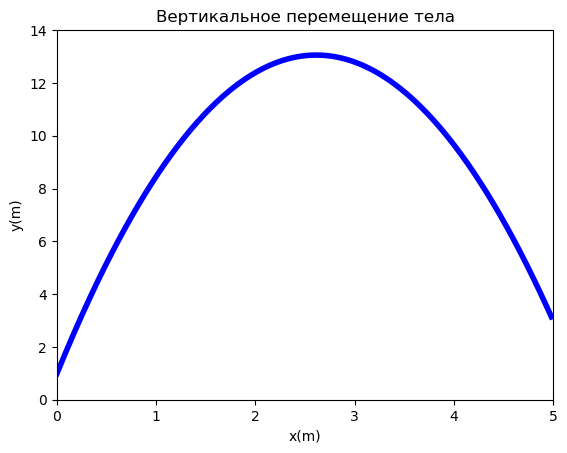

In [73]:
plt.figure()
plt.plot(sXList, sYList, 'b-', lw = 4)
plt.title('Вертикальное перемещение тела')
plt.xlabel('x(m)'); plt.ylabel('y(m)')
plt.axis([0, sEnd, 0, hEnd + 11]);

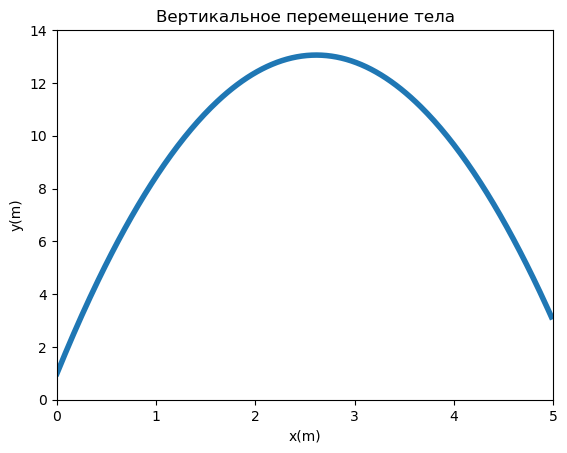

In [75]:
plt.figure()
plt.plot(sXArray, sYArray, lw = 4)
plt.title('Вертикальное перемещение тела')
plt.xlabel('x(m)'); plt.ylabel('y(m)')

plt.xlim(0, sEnd), plt.ylim(0, hEnd + 11);

## Задание 1.2. Определение момента времени касания телом земли

Для задачи о падении тела из Задания 1.1 момент времени касания телом
земли (время нахождения тела в воздухе).

Выполнение задания осуществите на основе двух подходов.

Подход 1 (**точное решение**): время касания телом земли находим как точное
решение уравнения ;

Подход 2 (**приближенное решение**):
- Постройте последовательность $s_{y}$ на временном отрезке $[0,tstop
]$, чтобы
момент касания тела земли $t∗$
 попадал в выбранный отрезок, т.е. $t ∗ ∈ [0,tstop]$.
Отметим, что $t_{stop}$ > $T$, где значение $T$ задается в Задании 1.1.
- Найдите в построенной последовательности два соседних элемента
последовательности, значения которых меняют знак. Т. е. найдите значение
индекса , для которого . Это будет означать, что
.
- Постройте прямую линию , проходящую через две точки и
 и найдите значение из условия
. Найденное значение , будет соответствовать точке на
прямой . в документе формулы для прямой
 и для вычисления .
найдите
sy(t) = 0
sy
[0,tstop
]
t
∗
t
∗ ∈ [0,tstop]
tstop > T T
sy
k sy
[k]sy
[k + 1] < 0
0 ∈ (sy[k], sy[k + 1])
slin(t) (t[k], sy
[k])
(t[k + 1], sy[k + 1]) t
∗ ∈ (t[k],t[k + 1])
slin(t
∗) = 0 t
∗ (t
∗
, 0)
slin(t) \color{red}\text{Приведите}
slin(t) t
∗
 точное решение (Подход 1) и приближенное решение
(Подход 2), вычислив относительную ошибку.


# Выполнение Задания 1.2

In [80]:
#Создание символьной переменной (относительно нее будет решаться уравнение)
T = sympy.symbols('t')

#Решение уравнения относительно t
result = sympy.solve(hStart + v0y * T - g * T ** 2 / 2, T)

for step, line in enumerate(result):
    print(f"Корень {step + 1}: {line}")

Корень 1: -0.0637382309488101
Корень 2: 3.19970039267921


In [81]:
tStartExact = result[-1]
print(f"Решение уравнения относительно перменной t: {tStartExact}")

Решение уравнения относительно перменной t: 3.19970039267921


**Спецификация функции *sympy.Symbol(name)***. Функция **Symbol** предназначена для создания символьных переменных, которые в дальнейшем используются в математических выражениях, уравнениях, полиномах и т.д. Аргумент **name** обязательно должен иметь тип данных **str**.

**Спецификация функции *sympy.solve(f, symbol, [flags])***. Функция **solve** используется для решения алгебраических уравнений, а также систем уравнений, матриц и т.д.

*Аргументы функции Solve:*

**f** — аргумент, указывающий, что будет решать функция: уравнение, систему уравнений, матрицы и т.д;<br>
**symbol** — символ (-ы) отночительно которого (-ых), будет предоставлено решение; <br>
**flags** — является необязательным аргументом, расширяет возможности вывода и способов тестирования функции **solve**.

## Подход 2

Уравнение прямой, проходящей через две точки:

$$\bf\frac{x - x_{1}}{x_{2} - x_{1}}=\frac{y - y_{1}}{y_{2} - y_{1}} \Rightarrow (x - x_{1})(y_{2} - y_{1})=(x_{2} - x_{1})(y - y_{1})$$

Для точки ($\bf t^*, 0$) уравнение примет вид:

$$\bf(t^* - x_{1})(y_{2} - y_{1})=(x_{2} - x_{1})y_{1}\Rightarrow t^* = \frac{(x_{2} - x_{1})y_{1}}{y_{2} - y_{1}} + x_{1}$$

где, $\bf(x_{1}, y_{1}) = (t[k], s_{y}[k])$ и, соответственно, $\bf(x_{2}, y_{2}) = (t[k + 1], s_{y}[k + 1])$.

In [89]:
timeSeqStep, step = 1e-8, 0
timeSeq = np.arange(t, t + 1, timeSeqStep)

ySeq = hStart + v0y * timeSeq - g * timeSeq ** 2 / 2
while True:
    if ySeq[step] * ySeq[step + 1] < 0:
        print(f"№ шага: {step}; ySeq[step]: {ySeq[step]}; ySeq[step + 1]: {ySeq[step + 1]}")
        break
    step += 1

x1, y1 = timeSeq[step], ySeq[step]
x2, y2 = timeSeq[step + 1], ySeq[step + 1]
tSolvingTheEquation = (x2 - x1) * y1 / (y2 - y1) + x1 

print(f"\nРешение: {tSolvingTheEquation}")

№ шага: 19970039; ySeq[step]: 6.229260662848901e-08; ySeq[step + 1]: -9.772439568678237e-08

Решение: 3.1997003848934527


In [91]:
tStartExact - tSolvingTheEquation

7.78575470761211e-9

# Задание 1.3. Построение секущей, касательной и нормали к графику функции


In [95]:
#Задание базовых параметров
directStart = np.array([sXArray[0], sYArray[0]])
directEnd = np.array([sXArray[-1], sYArray[-1]])

t1, t2 = -1, 2
#Вычислим направляющий вектор
aVector = directEnd - directStart
pointAB = [[(directStart + aVector * (t1))[step], (directStart + aVector * (t2))[step]] for step in range(2)]

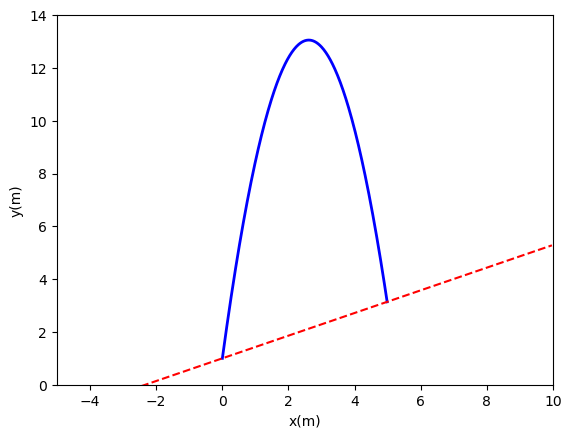

In [97]:
#Построим график траектории движения тела и график секущей в одной графической области
fig = plt.figure()
plt.plot(sXArray, sYArray, 'b-', lw = 2) 
plt.plot(pointAB[0], pointAB[1], '--', color = 'red', lw = 1.5)
plt.xlabel('x(m)'); plt.ylabel('y(m)')

plt.axis([-5, sEnd + 5, 0, hEnd + 11]);

Уравнение касательной выглядит следующим образом:
$$y-y_{0}=k\left(x-x_{0}\right)$$
Для того, чтобы найти угловой коэффициент $k$ касательной к графику полета тела в точке $(x_{start}, y_{start})$ и $t=0$, нужно:
1. Найти производные проекций перемещения по осям $Ox$ и $Oy$;
2. Из геометрического смысла тангенса следует, что 
$$tg\alpha = k = \frac{s_{y}^{'}(0)}{s_{x}^{'}(0)}=\frac{v_{0y} - g *0}{v_{0x}}\Rightarrow tg\alpha=\frac{v_{0y}}{v_{0x}}$$

Дальше по аналогии с прошлым заданием строим уравнение прямой и ищем две точки, принадлежащие ей. Приступим к реализации кода:

In [99]:
#Задаём начальные переменные
coeff = v0y / v0x

startPoint = np.array([-10, 10])
tanYArray = coeff * (startPoint - sXArray[0]) + sYArray[0]

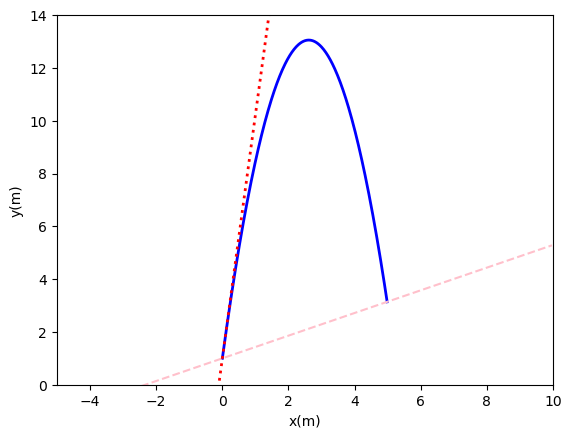

In [101]:
#Построение графика касательной и графика полета тела в одной графической плоскости
fig = plt.figure()
plt.plot(sXArray, sYArray, 'b-', lw = 2) 
plt.plot(pointAB[0], pointAB[1], '--', color = 'pink', lw = 1.5)
plt.plot(startPoint, tanYArray, 'r:', lw = 2) 
plt.xlabel('x(m)'); plt.ylabel('y(m)')

plt.axis([-5, sEnd + 5, 0, hEnd + 11]);

Уравнение нормали к касательной:
$$\bf y-y_{0}=k\left(x-x_{0}\right)$$
$$\bf \Rightarrow y-y_{0}=-\frac{1}{y^{\prime}\left(x_{0}\right)}\left(x-x_{0}\right)$$

Тут все правктически аналогично: берем коэффициент из уравнени касательной и подставляем в уравнение нормали (это следует из условия перпендикулярности прямых $\bf k_{1}k_{2}=-1$)

In [103]:
normCoeff = - 1 / coeff
normYArray = normCoeff * (startPoint - sXArray[0]) + sYArray[0]

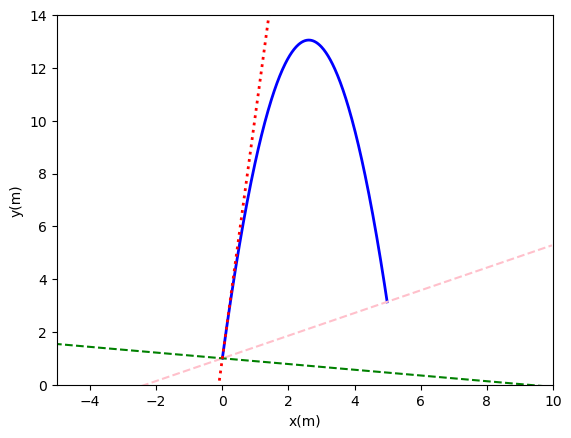

In [105]:
fig = plt.figure()
plt.plot(sXArray, sYArray, 'b-', lw = 2) 
plt.plot(pointAB[0], pointAB[1], '--', color = 'pink', lw = 1.5)
plt.plot(startPoint, normYArray, 'g--', lw = 1.5) 
plt.plot(startPoint, tanYArray, 'r:', lw = 2) 
plt.xlabel('x(m)'); plt.ylabel('y(m)')

plt.axis([-5, sEnd + 5, 0, hEnd + 11]);

# Задание 1.4. Построение графиков функций

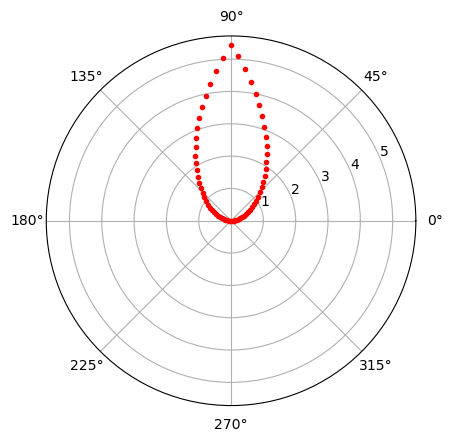

In [107]:
plt.figure()
# установка способа отображения осей
plt.axes(projection='polar')
# подготовка данных
phi = np.arange(-np.pi/2, np.pi/2, 0.05)
r = phi**3+phi
# построение графика
plt.plot(phi + (r<0)*np.pi,abs(r),'r.');


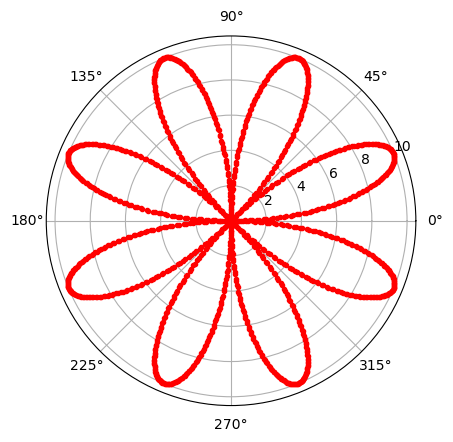

In [109]:
import math
plt.figure()
# установка способа отображения осей
plt.axes(projection='polar')
# подготовка данных
phi = np.arange(-2*np.pi, 2*np.pi, 0.01)
m = 12
a = 10
n = 3
r = a * np.sin(m * phi /n)
plt.plot(phi + (r<0)*np.pi,abs(r),'r.');

C:\Users\Sasha\AppData\Local\Temp\ipykernel_15680\1306215352.py:3: RuntimeWarning: invalid value encountered in sqrt
  xValueArray = (2*np.exp(tValueArray)-np.exp(tValueArray)**2)**(1/2)
C:\Users\Sasha\AppData\Local\Temp\ipykernel_15680\1306215352.py:4: RuntimeWarning: invalid value encountered in arcsin
  yValueArray = np.arcsin(np.exp(tValueArray) - 1)


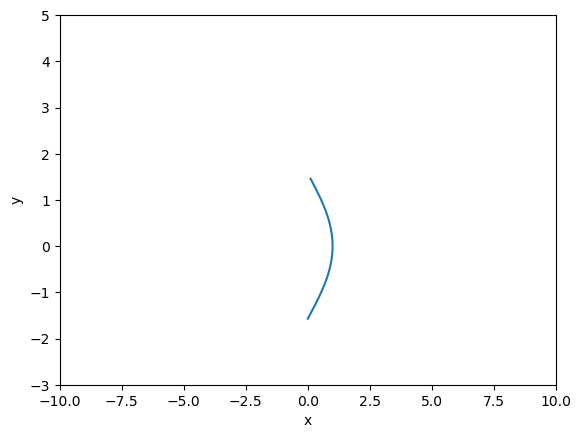

In [117]:
tValueArray = np.arange(-20, 20, 0.01)

xValueArray = (2*np.exp(tValueArray)-np.exp(tValueArray)**2)**(1/2)
yValueArray = np.arcsin(np.exp(tValueArray) - 1)

fig = plt.figure()
plt.plot(xValueArray, yValueArray)
plt.xlabel('x')
plt.ylabel('y')
plt.axis([-10, 10, -3, 5])
plt.show()